# Analisando Acidentes

Este documento descreve o processo técnico de organização e análise dos dados do RENAEST. O objetivo é compartilhar não apenas os resultados sobre segurança nas estradas, mas também o método utilizado para lidar com grandes volumes de dados de forma eficiente.

---

Configuração do notebook e importações

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## 1. O Desafio dos Dados Brutos

Trabalhar com o registro nacional de acidentes significa lidar com uma base que supera os 5 GB de informações. Quando os dados chegam até nós, eles estão em formato CSV, que é um formato de texto simples.

Embora o CSV seja fácil de ler por humanos, ele é ineficiente para processamento em larga escala, pois o computador precisa ler o arquivo linha por linha, do início ao fim, mesmo que queiramos saber apenas uma informação específica, como o "dia da semana".

## 2. Organização da Estrutura

Para gerenciar esse volume sem travar o processamento, organizei o projeto em três etapas lógicas no ambiente de nuvem (AWS S3 e Athena):

- **Camada Bronze:**
   Aqui, os arquivos CSV originais (Acidentes, Localidade, Veículos e Vítimas) são armazenados no Amazon S3. Guardando o dado bruto exatamente como ele foi gerado, assim obtendo garantia de que a fonte original está preservada.

- **Camada Prata:**
  Nesta etapa, conectamos o AWS Athena aos arquivos CSV da camada Bronze. Criamos tabelas que "espelham" o conteúdo dos arquivos. É aqui que definimos o que é cada coluna (números, textos, datas) e tratamos os erros de leitura, como campos vazios ou formatos inválidos. A partir daqui, já conseguimos fazer pesquisas usando SQL, embora a leitura do CSV ainda seja lenta pelo volume de dados.

  Exemplo:

  ```sql
    CREATE EXTERNAL TABLE IF NOT EXISTS `renasest`.`veiculos`(
      `num_acidente` BIGINT,
      `tipo_veiculo` STRING,
      `ind_veic_estrangeiro` STRING,
      `qtde_veiculos` BIGINT
    )
    ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
    WITH SERDEPROPERTIES (
      'separatorChar' = ';', 
      'quoteChar' = '"',
      'escapeChar' = '\\'
    )
    STORED AS TEXTFILE
    LOCATION 's3://r7melo-renasest-data/TipoVeiculo/'
    TBLPROPERTIES ('skip.header.line.count'='1');
    
  ```
  
- **Camada Gold:**
  Esta é a camada final e a mais importante para a performance. Criamos novas tabelas a partir da camada Prata, mas salvando os dados no formato Parquet. Ao contrário do CSV, o formato Gold organiza os dados de forma colunar e cria uma espécie de indexação automática. Isso permite que o sistema encontre informações específicas sem precisar ler o arquivo inteiro. O resultado é uma pesquisa muito mais veloz, transformando uma consulta de minutos em algo de poucos segundos.

  Exemplo:

  ```sql
    CREATE TABLE "renasest"."veiculos_gold"
    WITH (format = 'PARQUET', external_location = 's3://r7melo-renasest-views/gold_veiculos/')
    AS SELECT * FROM "renasest"."veiculos";

  ```


## 3. Sobre os Dados

Esta seção descreve as principais tabelas utilizadas na análise de acidentes de trânsito:

### Tabela de Vítimas

Esta tabela armazena informações demográficas, comportamentais e de gravidade relacionadas às vítimas envolvidas em cada acidente.

- **num_acidente**: Identificador único do acidente ao qual a vítima está associada.  
- **chv_localidade**: Chave de referência da localidade do acidente.  
- **data_acidente**: Data em que ocorreu o acidente.  
- **uf_acidente**: Unidade da Federação onde o acidente aconteceu.  
- **ano_acidente**: Ano de ocorrência do acidente.  
- **mes_acidente**: Mês de ocorrência do acidente (valor numérico).  
- **mes_ano_acidente**: Representação agregada de mês e ano do acidente (ex.: 2023-05).  

- **faixa_idade**: Classificação etária da vítima em faixas predefinidas.  
- **genero**: Sexo biológico da vítima.  
- **tp_envolvido**: Tipo de envolvimento da vítima no acidente (condutor, passageiro, pedestre, etc.).  
- **ind_motorista**: Indicador se a vítima era motorista (Sim/Não).  

- **gravidade_lesao**: Grau de severidade das lesões sofridas (Ileso, Ferido Leve, Ferido Grave, Óbito).  
- **equip_seguranca**: Indicação do uso de equipamento de segurança (cinto, capacete, cadeirinha).  
- **susp_alcool**: Indicador de suspeita de consumo de álcool (Sim/Não).  

- **qtde_envolvidos**: Quantidade total de pessoas envolvidas no acidente.  
- **qtde_feridosilesos**: Quantidade de vítimas classificadas como feridas ou ilesas.  
- **qtde_obitos**: Quantidade de óbitos registrados na ocorrência.

### Tabela de Veículos

Esta tabela descreve as características dos veículos envolvidos em cada ocorrência.

- **num_acidente**: Identificador único do acidente associado ao veículo.  
- **tipo_veiculo**: Categoria do veículo envolvido (Automóvel, Motocicleta, Caminhão, Ônibus, etc.).  
- **ind_veic_estrangeiro**: Indicador se o veículo possui registro estrangeiro (Sim/Não).  
- **qtde_veiculos**: Quantidade total de veículos envolvidos na ocorrência.

### Tabela de Localidade

Esta tabela contém informações geográficas, administrativas e estruturais da localidade do acidente.

- **chv_localidade**: Chave única de identificação da localidade.  
- **ano_referencia**: Ano de referência das informações da localidade.  
- **mes_referencia**: Mês de referência das informações (valor numérico).  
- **mes_ano_referencia**: Representação agregada de mês e ano de referência (ex.: 2023-05).  
- **regiao**: Região geográfica do Brasil (Norte, Nordeste, Sudeste, Sul, Centro-Oeste).  
- **uf**: Unidade da Federação.  
- **codigo_ibge**: Código IBGE do município.  
- **municipio**: Nome do município.  
- **regiao_metropolitana**: Indicação se o município pertence a uma região metropolitana.  
- **qtde_habitantes**: Quantidade de habitantes do município (Censo 2022).  
- **frota_total**: Quantidade total de veículos registrados no município.  
- **frota_circulante**: Quantidade estimada de veículos em circulação no município.

### Tabela de Acidentes

Esta tabela reúne informações temporais, ambientais e operacionais do acidente.

- **num_acidente**: Identificador único do acidente.  
- **chv_localidade**: Chave de referência da localidade onde ocorreu o acidente.  
- **data_acidente**: Data em que o acidente ocorreu.  
- **uf_acidente**: Unidade da Federação onde o acidente aconteceu.  
- **ano_acidente**: Ano de ocorrência do acidente.  
- **mes_acidente**: Mês de ocorrência do acidente (valor numérico).  
- **mes_ano_acidente**: Representação agregada de mês e ano do acidente (ex.: 2023-05).  
- **codigo_ibge**: Código IBGE do município da ocorrência.  
- **dia_semana**: Dia da semana em que ocorreu o acidente.  
- **fase_dia**: Classificação do período do dia (Amanhecer, Pleno dia, Anoitecer, Plena noite).  
- **tp_acidente**: Tipo do acidente (colisão, atropelamento, capotamento, etc.).  
- **cond_meteorologica**: Condição climática no momento do acidente (Céu Limpo, Chuva, Nublado, etc.).  
- **end_acidente**: Endereço ou descrição do local onde ocorreu o acidente.


## 4. Extração de Insights

Nesta etapa, utilizamos o poder de processamento do AWS Athena sobre a camada Gold para extrair apenas os resumos necessários.

### Análise por Contagem das Ocorrências Temporais



- **Contagem por Condição Meteorológica**
 
    Query:
    ```sql
    SELECT fase_dia, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY fase_dia
    ORDER BY contagem DESC;
    
    
    ```

    Resultado:
  

<Axes: xlabel='contagem', ylabel='cond_meteorologica'>

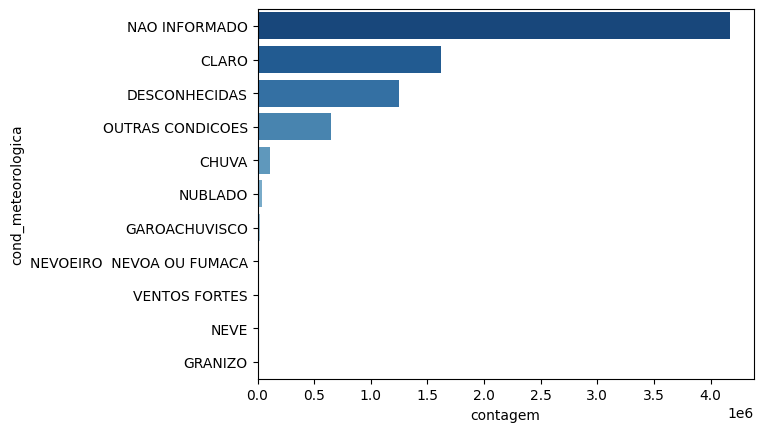

In [40]:
df_clima = pd.read_csv("./query-results/Contagem por Condição Meteorológica.csv")

sns.barplot(
    data=df_clima, 
    x='contagem', 
    y='cond_meteorologica', 
    palette='Blues_r', 
    hue='cond_meteorologica', 
    legend=False               
)

- **Contagem por Fase do Dia**
 
    Query:
    ```sql
    SELECT fase_dia, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY fase_dia
    ORDER BY contagem DESC;
    
    
    ```

    Resultado:
  

<Axes: xlabel='contagem', ylabel='fase_dia'>

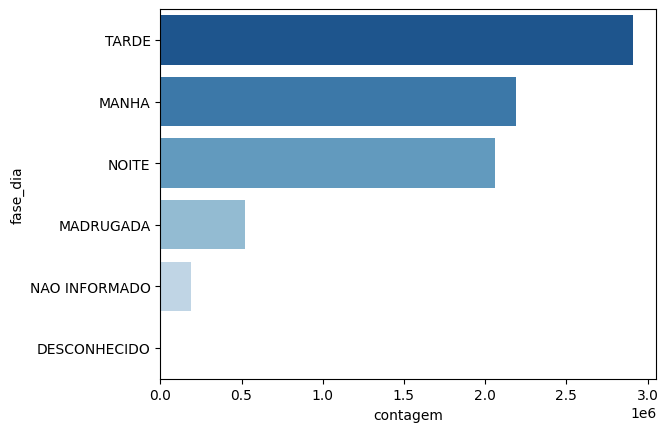

In [42]:
df_fase_dia = pd.read_csv("./query-results/Contagem por Fase do Dia.csv")

sns.barplot(
    data=df_fase_dia, 
    x='contagem', 
    y='fase_dia', 
    palette='Blues_r', 
    hue='fase_dia', 
    legend=False               
)

- **Contagem por Dia da Semana**
 
    Query:
    ```sql
    SELECT dia_semana, COUNT(*) as contagem
    FROM "renasest"."acidentes_gold"
    GROUP BY dia_semana
    ORDER BY contagem DESC;
        
    
    ```

    Resultado:
  

<Axes: xlabel='contagem', ylabel='dia_semana'>

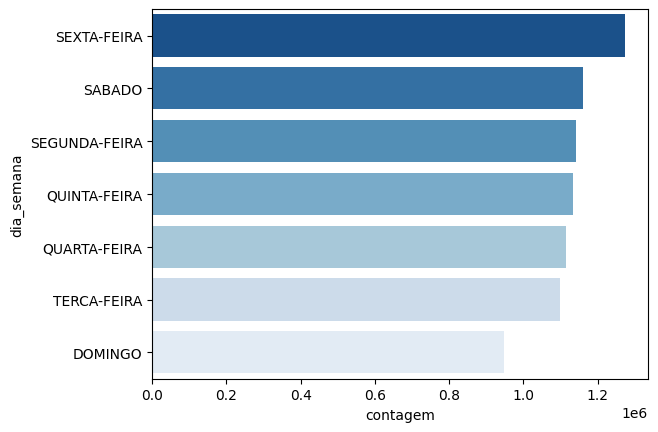

In [43]:
df_fase_dia = pd.read_csv("./query-results/Contagem por Dia da Semana.csv")

sns.barplot(
    data=df_fase_dia, 
    x='contagem', 
    y='dia_semana', 
    palette='Blues_r', 
    hue='dia_semana', 
    legend=False               
)

### Análise das vítimas por genero

- **Total de Vítimas**

<Axes: xlabel='total_vitimas', ylabel='genero'>

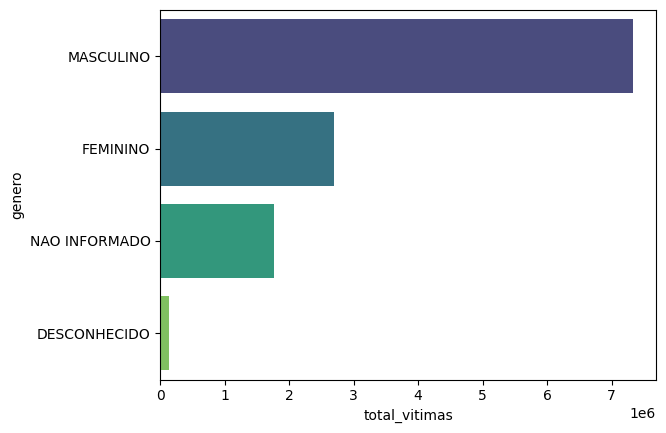

In [52]:
sns.barplot(
    data=df_genero, 
    x='total_vitimas', 
    y='genero', 
    hue='genero', 
    palette='viridis', 
    legend=False
)

- **Total de Mortos**

<Axes: xlabel='total_obitos', ylabel='genero'>

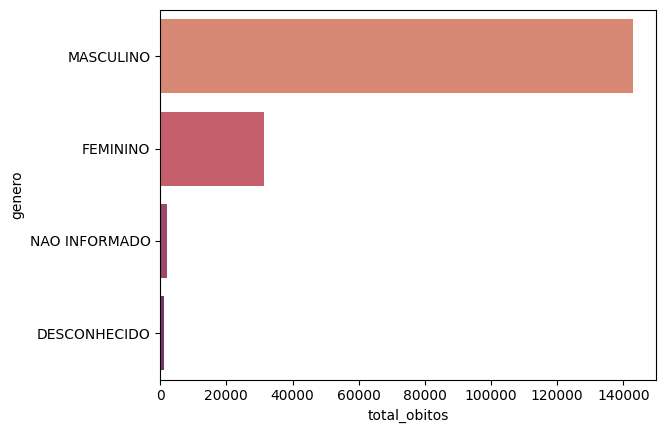

In [55]:
sns.barplot(
    data=df_genero, 
    x='total_obitos', 
    y='genero', 
    hue='genero', 
    palette='flare', 
    legend=False
)

### Análise da Tabela Temporal por Genero
Essa tabela foi gerada pelo sequinte query:

```sql
SELECT 
    a.cond_meteorologica, 
    a.fase_dia, 
    a.dia_semana, 
    COUNT(CASE WHEN v.genero = 'MASCULINO' THEN 1 END) as vitimas_homens,
    COUNT(CASE WHEN v.genero = 'FEMININO' THEN 1 END) as vitimas_mulheres,
    SUM(CASE WHEN v.genero = 'MASCULINO' THEN v.qtde_obitos ELSE 0 END) as mortos_homens,
    SUM(CASE WHEN v.genero = 'FEMININO' THEN v.qtde_obitos ELSE 0 END) as mortos_mulheres,
    SUM(v.qtde_obitos) as total_mortos_geral
FROM "renasest"."acidentes_gold" a
JOIN "renasest"."vitimas_gold" v ON a.num_acidente = v.num_acidente
GROUP BY 
    a.cond_meteorologica, 
    a.fase_dia, 
    a.dia_semana
ORDER BY total_mortos_geral DESC
```

- Head do DataFrame

In [61]:
ttpg = pd.read_csv("./query-results/Tabela Temporal por Genero.csv")
ttpg.head()

,cond_meteorologica,fase_dia,dia_semana,vitimas_homens,vitimas_mulheres,mortos_homens,mortos_mulheres,total_mortos_geral
0,NAO INFORMADO,NOITE,DOMINGO,146178,46916,5187,1090,6422
1,NAO INFORMADO,NOITE,SABADO,167409,51014,4818,898,5861
2,NAO INFORMADO,MADRUGADA,DOMINGO,58036,16251,3462,638,4227
3,NAO INFORMADO,NOITE,SEXTA-FEIRA,176972,59961,3366,672,4111
4,NAO INFORMADO,TARDE,DOMINGO,148330,51269,2938,678,3713


In [65]:
df = ttpg.copy()

### Análise da Tabela Mortos Durante a Semana Por Fase do Dia

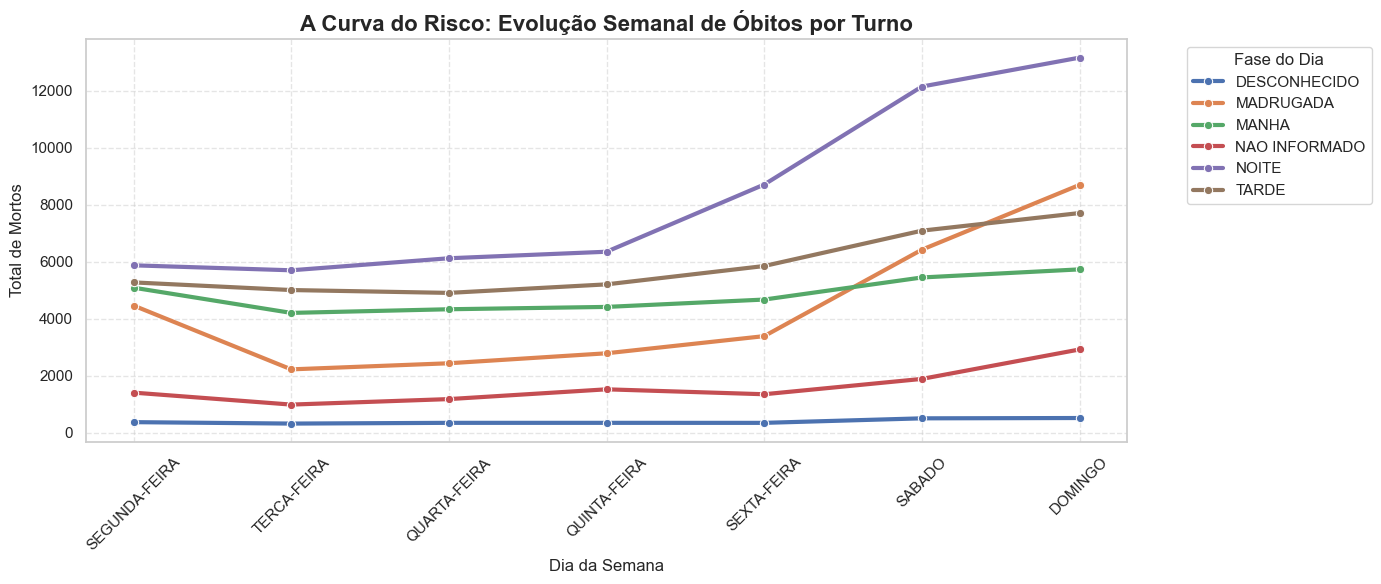

In [81]:
tmns = pd.read_csv("./query-results/Tabela Mortos na Semana por Fase do Dia.csv")

ordem_dias = ['SEGUNDA-FEIRA', 'TERCA-FEIRA', 'QUARTA-FEIRA', 'QUINTA-FEIRA', 'SEXTA-FEIRA', 'SABADO', 'DOMINGO']

tmns['dia_semana'] = pd.Categorical(tmns['dia_semana'], categories=ordem_dias, ordered=True)

df_plot = tmns.groupby(['dia_semana', 'fase_dia'], observed=False)['total_mortos'].sum().fillna(0).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_plot, 
    x='dia_semana', 
    y='total_mortos', 
    hue='fase_dia', 
    marker='o',      
    linewidth=3,     
    errorbar=None    
)

plt.title('A Curva do Risco: Evolução Semanal de Óbitos por Turno', fontsize=16, fontweight='bold')
plt.ylabel('Total de Mortos')
plt.xlabel('Dia da Semana')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Fase do Dia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Análise da Tabela Mortos Durante a Semana Por Genero

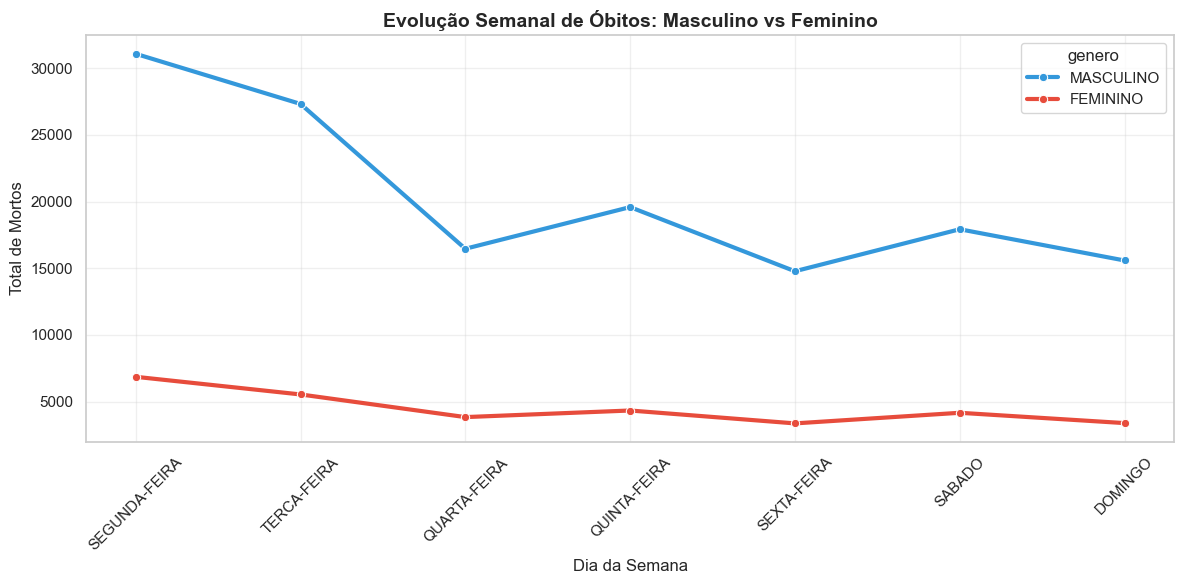

In [91]:
tmsg = pd.read_csv("./query-results/Tabela Mortos na Semana por Genero.csv")

ordem_dias = ['SEGUNDA-FEIRA', 'TERCA-FEIRA', 'QUARTA-FEIRA', 'QUINTA-FEIRA', 'SEXTA-FEIRA', 'SABADO', 'DOMINGO']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=tmsg, 
    x='dia_semana', 
    y='total_mortos', 
    hue='genero', 
    marker='o',
    palette=['#3498db', '#e74c3c'], # Azul para Masculino, Vermelho para Feminino
    linewidth=3
)

plt.xticks(ticks=range(len(ordem_dias)), labels=ordem_dias, rotation=45)
plt.title('Evolução Semanal de Óbitos: Masculino vs Feminino', fontsize=14, fontweight='bold')
plt.ylabel('Total de Mortos')
plt.xlabel('Dia da Semana')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()